# 📈 Notebook 03 · Series de Tiempo y Valorización
---
**Proyecto:** Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano  
**Fuente:** UAECD / IDECA · 2020–2026  
**Autor:** Kevin Palacio Martinez

---
## 🎯 Objetivo

Analizar la evolución temporal del valor comercial por m² en Bogotá,
identificar tasas de valorización por localidad, detectar quiebres
estructurales en la serie y comparar contra indicadores macroeconómicos
como el IPC y el índice de costos de construcción.

## 📋 Contenido

| Sección | Descripción |
|---|---|
| 1 | Carga y preparación de la serie de tiempo |
| 2 | Tasa de valorización anual por localidad |
| 3 | Ranking de localidades — mayor y menor valorización acumulada |
| 4 | Comparación contra inflación IPC — valorización real vs nominal |
| 5 | Detección de quiebres estructurales en la serie |
| 6 | Manzanas con mayor y menor valorización acumulada |
| 7 | Exportación de resultados |

---
## ⚙️ Sección 1 · Carga y preparación de la serie de tiempo

> Se carga el dataset limpio desde el archivo Parquet generado en el notebook 01.  

> Se trabaja exclusivamente con `valor_final` (con imputación aplicada)  
> y se filtran las zonas urbanas y periurbanas para el análisis de valorización.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from db_config import DB_URL

pd.set_option('display.float_format', '{:,.0f}'.format)
sns.set_theme(style="whitegrid", font_scale=1.1)

# Carga desde parquet
df = pd.read_parquet('../data/processed/valor_manzana_limpio.parquet')

# Filtrar solo urbano y periurbano para análisis de valorización
df_urbano = df[df['tipo_territorio'].isin(['urbano', 'periurbano'])].copy()

print(f"✓ Registros totales    : {len(df):,}")
print(f"✓ Registros urbanos    : {len(df_urbano):,}")
print(f"✓ Años disponibles     : {sorted(df_urbano['anio'].unique())}")
print(f"✓ Localidades          : {df_urbano['localidad'].nunique()}")

✓ Registros totales    : 299,482
✓ Registros urbanos    : 298,120
✓ Años disponibles     : [2020, 2021, 2022, 2023, 2024, 2025, 2026]
✓ Localidades          : 19


---
## 📊 Sección 2 · Tasa de valorización anual por localidad

> Se calcula la variación porcentual de la mediana del valor por m²
> entre años consecutivos para cada localidad.  
> Esto permite identificar qué zonas lideran la valorización y cuáles
> muestran rezago o desvalorización en períodos específicos.

── Serie de tiempo por localidad (primeras filas) ───────


,localidad,anio,mediana,variacion_pct,base_2020,valorizacion_acumulada
0,ANTONIO NARIÑO,2020,"2,100,000",NaN,"2,100,000",0
1,ANTONIO NARIÑO,2021,"2,362,500",12,"2,100,000",12
2,ANTONIO NARIÑO,2022,"2,400,000",2,"2,100,000",14
3,ANTONIO NARIÑO,2023,"2,620,000",9,"2,100,000",25
4,ANTONIO NARIÑO,2024,"2,820,000",8,"2,100,000",34
5,ANTONIO NARIÑO,2025,"3,000,000",6,"2,100,000",43
6,ANTONIO NARIÑO,2026,"3,200,000",7,"2,100,000",52
7,BARRIOS UNIDOS,2020,"2,750,000",NaN,"2,750,000",0
8,BARRIOS UNIDOS,2021,"3,000,000",9,"2,750,000",9
9,BARRIOS UNIDOS,2022,"3,000,000",0,"2,750,000",9


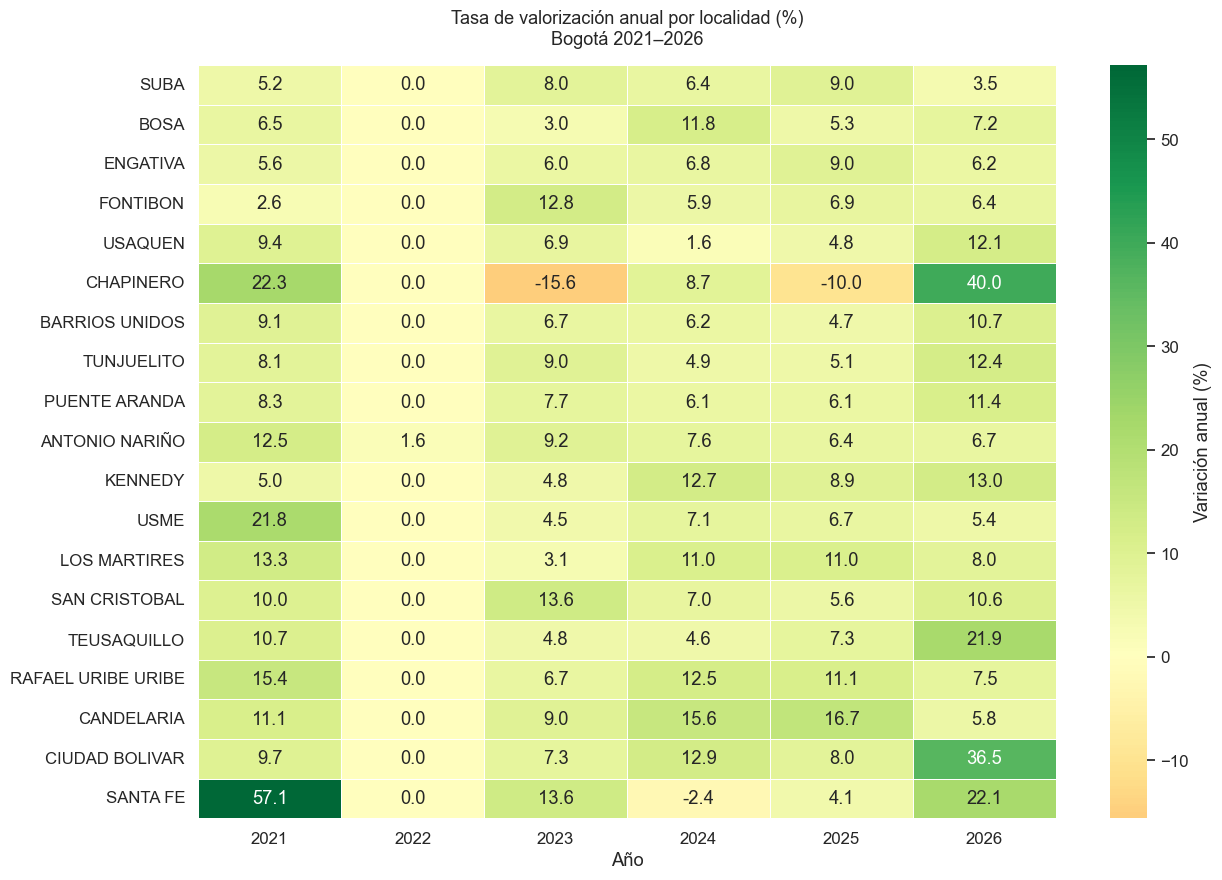

✓ Gráfico guardado en reports/figures/


In [2]:
# Mediana por localidad y año
serie_localidad = (
    df_urbano[df_urbano['valor_final'] > 0]
    .groupby(['localidad', 'anio'])['valor_final']
    .median()
    .reset_index()
    .rename(columns={'valor_final': 'mediana'})
    .sort_values(['localidad', 'anio'])
)

# Variación porcentual anual
serie_localidad['variacion_pct'] = (
    serie_localidad.groupby('localidad')['mediana']
    .pct_change() * 100
).round(2)

# Valorización acumulada 2020-2026
base_2020 = serie_localidad[serie_localidad['anio'] == 2020][['localidad', 'mediana']].rename(
    columns={'mediana': 'base_2020'}
)
serie_localidad = serie_localidad.merge(base_2020, on='localidad', how='left')
serie_localidad['valorizacion_acumulada'] = (
    (serie_localidad['mediana'] - serie_localidad['base_2020']) /
    serie_localidad['base_2020'] * 100
).round(2)

print("── Serie de tiempo por localidad (primeras filas) ───────")
display(serie_localidad.head(14))

# Heatmap de variación anual por localidad
pivot_var = serie_localidad[serie_localidad['anio'] > 2020].pivot(
    index='localidad', columns='anio', values='variacion_pct'
)

# Ordenar por valorización acumulada total
orden = (
    serie_localidad[serie_localidad['anio'] == 2026]
    .sort_values('valorizacion_acumulada', ascending=True)['localidad']
    .tolist()
)
pivot_var = pivot_var.loc[orden]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    pivot_var,
    annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.4, linecolor='white',
    ax=ax, cbar_kws={'label': 'Variación anual (%)'}
)
ax.set_title('Tasa de valorización anual por localidad (%)\nBogotá 2021–2026',
             fontsize=13, pad=15)
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/08_heatmap_valorizacion_localidad.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🏆 Sección 3 · Ranking — Mayor y menor valorización acumulada

> Identificación de las localidades con mayor y menor valorización
> acumulada entre 2020 y 2026, con análisis de la trayectoria
> de cada una en el período.

── Ranking de valorización acumulada 2020–2026 ──────────


,localidad,valor_2020,valor_2026,valorizacion_acumulada
0,SANTA FE,"700,000","1,550,000",121
1,CIUDAD BOLIVAR,"620,000","1,215,000",96
2,CANDELARIA,"1,800,000","3,111,000",73
3,RAFAEL URIBE URIBE,"1,300,000","2,150,000",65
4,TEUSAQUILLO,"2,800,000","4,450,000",59
5,SAN CRISTOBAL,"800,000","1,250,000",56
6,LOS MARTIRES,"2,250,000","3,500,000",56
7,USME,"550,000","843,000",53
8,KENNEDY,"2,000,000","3,050,000",52
9,ANTONIO NARIÑO,"2,100,000","3,200,000",52


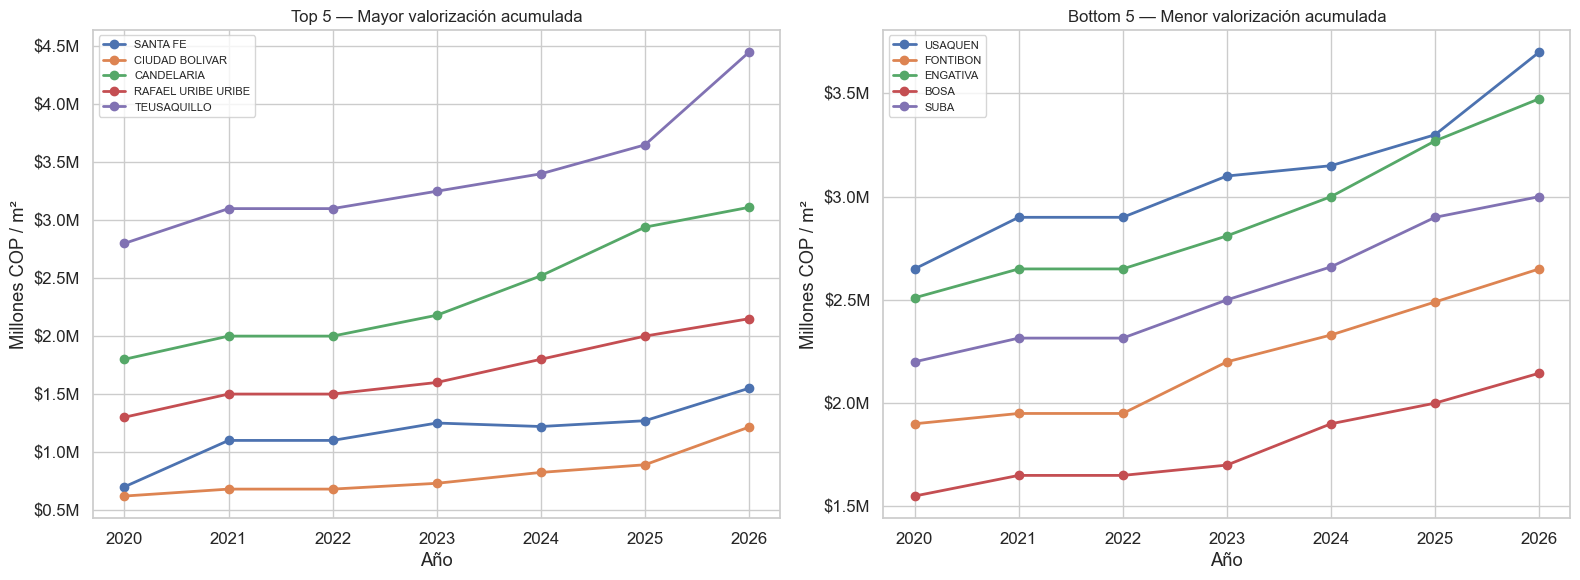

✓ Gráfico guardado en reports/figures/


In [3]:
# Valorización acumulada 2020-2026
ranking_acumulado = (
    serie_localidad[serie_localidad['anio'] == 2026]
    [['localidad', 'base_2020', 'mediana', 'valorizacion_acumulada']]
    .rename(columns={
        'base_2020': 'valor_2020',
        'mediana':   'valor_2026'
    })
    .sort_values('valorizacion_acumulada', ascending=False)
    .reset_index(drop=True)
)

print("── Ranking de valorización acumulada 2020–2026 ──────────")
display(ranking_acumulado)

# Top 5 y Bottom 5
top5    = ranking_acumulado.head(5)['localidad'].tolist()
bottom5 = ranking_acumulado.tail(5)['localidad'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grupo, titulo, color in zip(
    axes,
    [top5, bottom5],
    ['Top 5 — Mayor valorización acumulada',
     'Bottom 5 — Menor valorización acumulada'],
    ['#16A34A', '#DC2626']
):
    datos = serie_localidad[serie_localidad['localidad'].isin(grupo)]
    for localidad in grupo:
        d = datos[datos['localidad'] == localidad]
        ax.plot(d['anio'], d['mediana'] / 1_000_000,
                marker='o', linewidth=2, label=localidad)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Millones COP / m²')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/09_top_bottom_valorizacion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 💰 Sección 4 · Comparación contra inflación IPC

> Para determinar si la valorización del suelo representa un
> **crecimiento real** o simplemente sigue la inflación, se compara
> la variación anual de la mediana urbana contra el IPC anual
> publicado por el DANE.
>
> **IPC Colombia (fuente DANE):**
>
> | Año | IPC anual (%) |
> |---|---|
> | 2021 | 5.62 |
> | 2022 | 13.12 |
> | 2023 | 9.28 |
> | 2024 | 5.20 |
> | 2025 | 5.10 |
> | 2026 | — (proyección) |
>
> Fuente: DANE — Índice de Precios al Consumidor, serie anual.

── Valorización nominal vs real (descontado IPC) ────────


,anio,variacion_bogota,ipc,valorizacion_real
0,2021,12,6,6
1,2022,0,13,-13
2,2023,8,9,-1
3,2024,5,5,-0
4,2025,10,5,5
5,2026,10,NaN,NaN


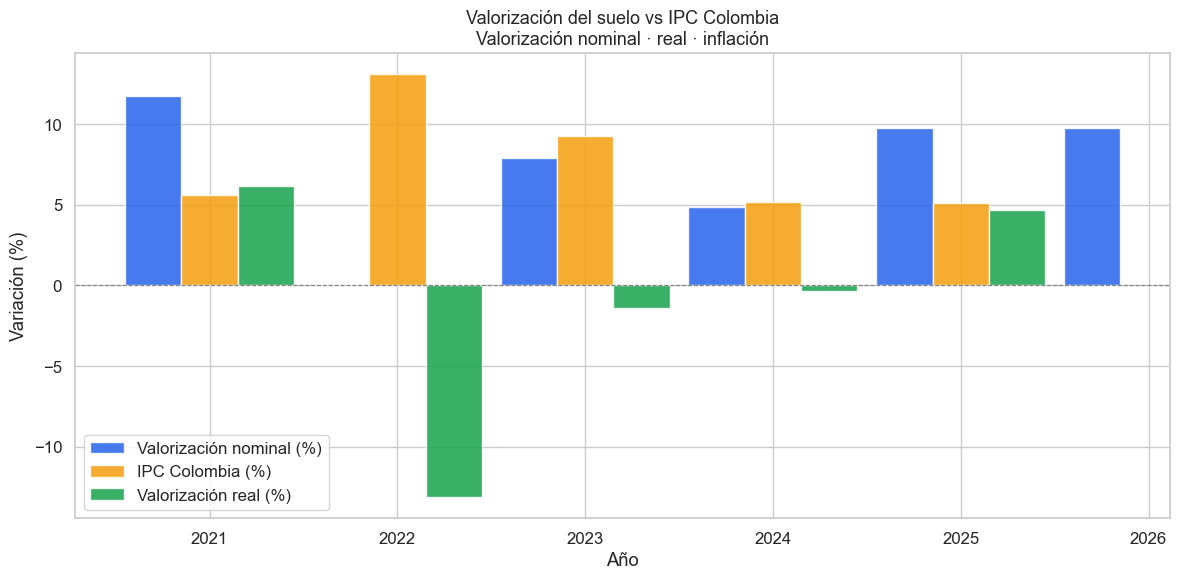

✓ Gráfico guardado en reports/figures/


In [4]:
# IPC anual DANE
ipc = pd.DataFrame({
    'anio': [2021, 2022, 2023, 2024, 2025],
    'ipc':  [5.62, 13.12, 9.28, 5.20, 5.10]
})

# Variación anual mediana urbana total
serie_total = (
    df_urbano[df_urbano['valor_final'] > 0]
    .groupby('anio')['valor_final']
    .median()
    .pct_change()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'valor_final': 'variacion_bogota'})
)

comparacion = serie_total[serie_total['anio'] > 2020].merge(ipc, on='anio', how='left')
comparacion['valorizacion_real'] = (comparacion['variacion_bogota'] - comparacion['ipc']).round(2)

print("── Valorización nominal vs real (descontado IPC) ────────")
display(comparacion)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparacion))
ancho = 0.3

bars1 = ax.bar(x - ancho, comparacion['variacion_bogota'], ancho,
               label='Valorización nominal (%)', color='#2563EB', alpha=0.85)
bars2 = ax.bar(x,          comparacion['ipc'],              ancho,
               label='IPC Colombia (%)',          color='#F59E0B', alpha=0.85)
bars3 = ax.bar(x + ancho,  comparacion['valorizacion_real'], ancho,
               label='Valorización real (%)',     color='#16A34A', alpha=0.85)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(comparacion['anio'])
ax.set_title('Valorización del suelo vs IPC Colombia\nValorización nominal · real · inflación',
             fontsize=13)
ax.set_ylabel('Variación (%)')
ax.set_xlabel('Año')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/10_valorizacion_vs_ipc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🔍 Sección 5 · Detección de quiebres estructurales

> Un **quiebre estructural** es un punto en el tiempo donde la
> tendencia de la serie cambia de forma significativa y sostenida.  
> Se usa el test de **Chow** simplificado y análisis visual de
> la primera diferencia para identificar años de cambio de tendencia
> en la serie de Bogotá y por localidad.
>
> Contexto relevante:
> - **2022** — Inicio del ciclo de alza de tasas del Banco de la República
> - **2023** — Tasas de interés en máximos históricos (13.25%)
> - **2024** — Inicio del ciclo de recorte de tasas

── Primera diferencia de la serie urbana ────────────────


,anio,mediana,delta,delta_pct
0,2020,"1,700,000",NaN,NaN
1,2021,"1,900,000","200,000",12
2,2022,"1,900,000",0,0
3,2023,"2,050,000","150,000",8
4,2024,"2,150,000","100,000",5
5,2025,"2,360,000","210,000",10
6,2026,"2,590,000","230,000",10


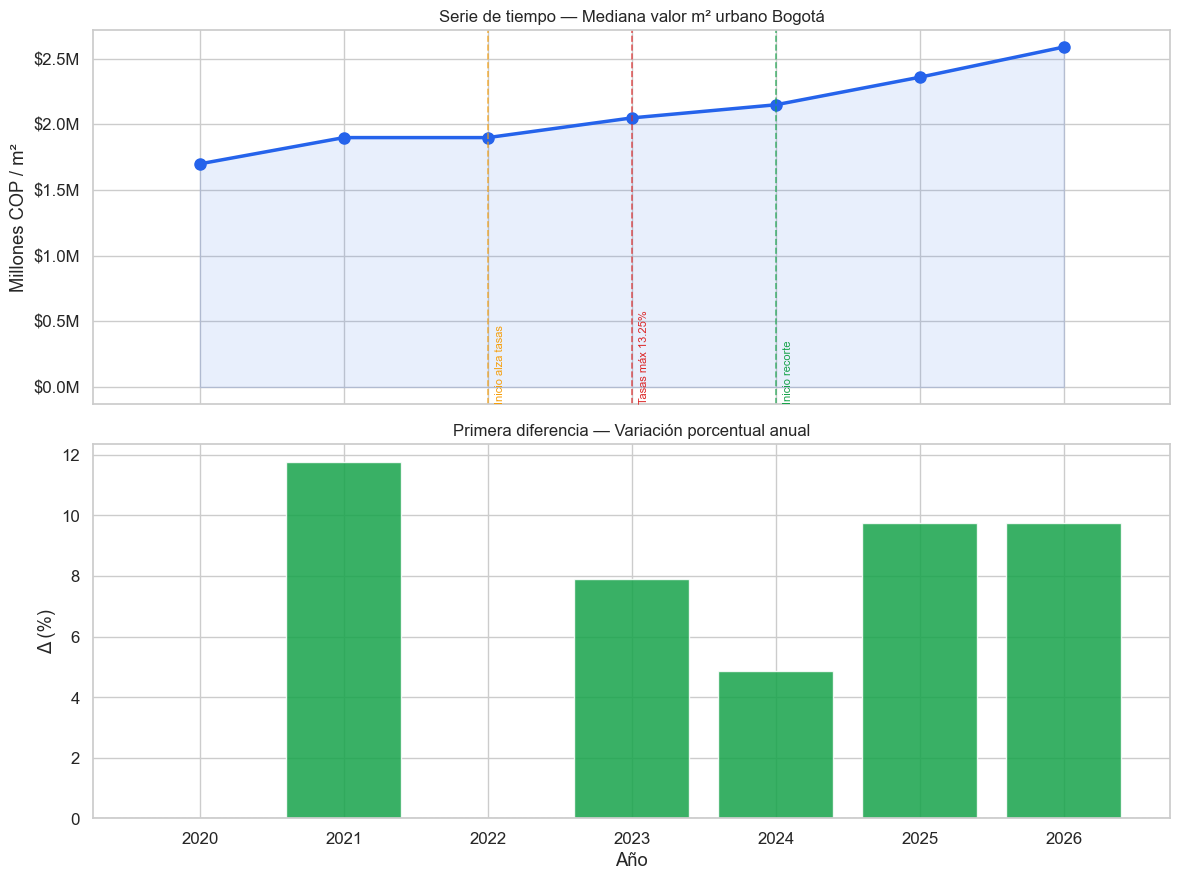

✓ Gráfico guardado en reports/figures/


In [5]:
from scipy import stats

# Serie total urbana
serie_urbana = (
    df_urbano[df_urbano['valor_final'] > 0]
    .groupby('anio')['valor_final']
    .median()
    .reset_index()
    .rename(columns={'valor_final': 'mediana'})
)

# Primera diferencia
serie_urbana['delta'] = serie_urbana['mediana'].diff()
serie_urbana['delta_pct'] = serie_urbana['mediana'].pct_change() * 100

print("── Primera diferencia de la serie urbana ────────────────")
display(serie_urbana)

# Visualización — serie + primera diferencia
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Serie original
axes[0].plot(serie_urbana['anio'], serie_urbana['mediana'] / 1_000_000,
             marker='o', linewidth=2.5, color='#2563EB', markersize=8)
axes[0].fill_between(serie_urbana['anio'],
                     serie_urbana['mediana'] / 1_000_000,
                     alpha=0.1, color='#2563EB')
axes[0].set_title('Serie de tiempo — Mediana valor m² urbano Bogotá', fontsize=12)
axes[0].set_ylabel('Millones COP / m²')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Líneas de contexto macroeconómico
for anio, etiqueta, color in [
    (2022, 'Inicio alza tasas', '#F59E0B'),
    (2023, 'Tasas máx 13.25%', '#DC2626'),
    (2024, 'Inicio recorte',   '#16A34A')
]:
    axes[0].axvline(anio, color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    axes[0].text(anio + 0.05, axes[0].get_ylim()[0], etiqueta,
                fontsize=8, color=color, rotation=90, va='bottom')

# Primera diferencia
colores_delta = ['#16A34A' if v >= 0 else '#DC2626'
                 for v in serie_urbana['delta_pct'].fillna(0)]
axes[1].bar(serie_urbana['anio'], serie_urbana['delta_pct'].fillna(0),
            color=colores_delta, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Primera diferencia — Variación porcentual anual', fontsize=12)
axes[1].set_ylabel('Δ (%)')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.savefig('../reports/figures/11_quiebres_estructurales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🏘️ Sección 6 · Manzanas con mayor y menor valorización acumulada

> Análisis a nivel de manzana para identificar los predios específicos
> con mayor y menor valorización en el período 2020–2026.  
> Este análisis es el insumo directo para el modelo predictivo
> del notebook 04.

▸ Manzanas con serie completa 2020–2026 : 41,134

── Top 10 manzanas más valorizadas ──────────────────────


,cod_manzana,localidad,sector,2020,2026,valorizacion_acumulada
0,002422020,CIUDAD BOLIVAR,ATLANTA,"9,500","1,428,000","14,932"
1,009116025,SUBA,PRADO VERANIEGO NORTE,"31,400","3,900,000","12,320"
2,001318009,SAN CRISTOBAL,QUINDIO,"6,900","807,465","11,602"
3,002525073,USME,BARRANQUILLITA,"10,400","1,159,000","11,044"
4,001318007,SAN CRISTOBAL,QUINDIO,"6,900","638,657","9,156"
5,004589015,BOSA,SAN PEDRO,"21,900","1,973,817","8,913"
6,004597070,BOSA,SAN BERNARDINO I,"21,900","1,930,000","8,713"
7,002599021,USME,CENTRO USME URBANO,"9,700","847,463","8,637"
8,002447001,CIUDAD BOLIVAR,EL MIRADOR DE LA ESTANCIA,"9,500","790,000","8,216"
9,002447002,CIUDAD BOLIVAR,EL MIRADOR DE LA ESTANCIA,"9,500","790,000","8,216"



── Top 10 manzanas menos valorizadas ────────────────────


,cod_manzana,localidad,sector,2020,2026,valorizacion_acumulada
0,001428050,RAFAEL URIBE URIBE,CERROS DE ORIENTE,"330,000","4,000",-99
1,006313039,FONTIBON,SALITRE OCCIDENTAL,"2,100,000","70,000",-97
2,006313040,FONTIBON,SALITRE OCCIDENTAL,"2,100,000","70,000",-97
3,006313058,FONTIBON,SALITRE OCCIDENTAL,"2,100,000","70,000",-97
4,001422051,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"390,000","15,000",-96
5,001422076,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"390,000","15,000",-96
6,001422057,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"1,300,000","50,600",-96
7,001422060,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"1,300,000","50,600",-96
8,001422061,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"1,300,000","50,600",-96
9,001422062,RAFAEL URIBE URIBE,DIANA TURBAY ARRAYANES,"1,300,000","50,600",-96


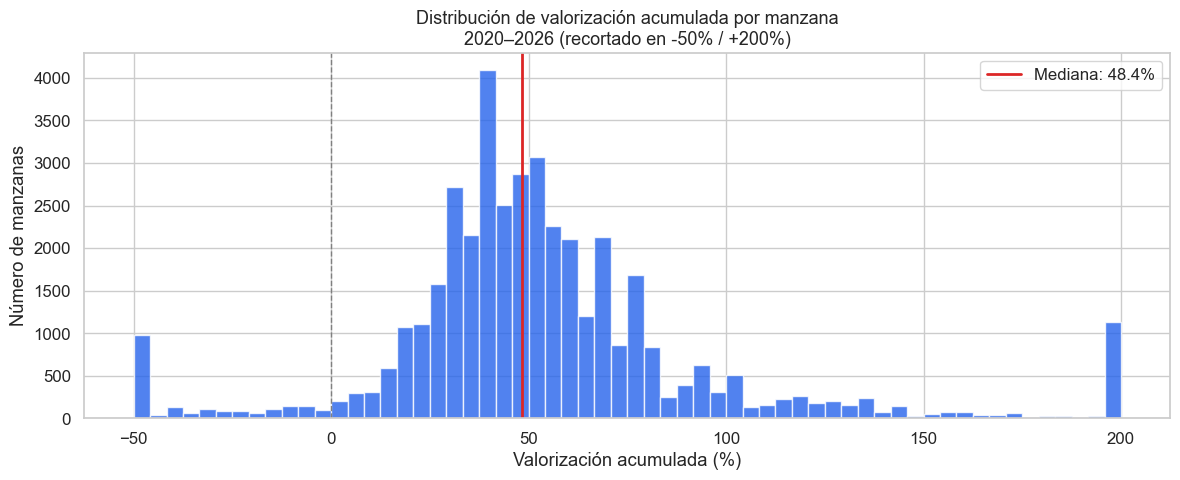

✓ Gráfico guardado en reports/figures/


In [6]:
# Pivot por manzana
pivot_manzana = (
    df_urbano[df_urbano['valor_final'] > 0]
    .pivot_table(
        index=['cod_manzana', 'localidad', 'sector'],
        columns='anio',
        values='valor_final',
        aggfunc='median'
    )
    .reset_index()
)
pivot_manzana.columns.name = None

# Solo manzanas con datos en 2020 y 2026
pivot_manzana = pivot_manzana.dropna(subset=[2020, 2026])
pivot_manzana['valorizacion_acumulada'] = (
    (pivot_manzana[2026] - pivot_manzana[2020]) /
    pivot_manzana[2020] * 100
).round(2)

print(f"▸ Manzanas con serie completa 2020–2026 : {len(pivot_manzana):,}")
print(f"\n── Top 10 manzanas más valorizadas ──────────────────────")
display(
    pivot_manzana.nlargest(10, 'valorizacion_acumulada')
    [['cod_manzana', 'localidad', 'sector', 2020, 2026, 'valorizacion_acumulada']]
    .reset_index(drop=True)
)

print(f"\n── Top 10 manzanas menos valorizadas ────────────────────")
display(
    pivot_manzana.nsmallest(10, 'valorizacion_acumulada')
    [['cod_manzana', 'localidad', 'sector', 2020, 2026, 'valorizacion_acumulada']]
    .reset_index(drop=True)
)

# Distribución de valorización acumulada
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(
    pivot_manzana['valorizacion_acumulada'].clip(-50, 200),
    bins=60, color='#2563EB', alpha=0.8, edgecolor='white'
)
ax.axvline(pivot_manzana['valorizacion_acumulada'].median(),
           color='#DC2626', linewidth=2,
           label=f"Mediana: {pivot_manzana['valorizacion_acumulada'].median():.1f}%")
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_title('Distribución de valorización acumulada por manzana\n2020–2026 (recortado en -50% / +200%)',
             fontsize=13)
ax.set_xlabel('Valorización acumulada (%)')
ax.set_ylabel('Número de manzanas')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/12_distribucion_valorizacion_manzana.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

In [8]:
# ── Detección y exclusión de manzanas con variación anómala ───

UMBRAL_MAX =  500   # % máximo de variación acumulada considerado real
UMBRAL_MIN =  -80   # % mínimo de variación acumulada considerado real

manzanas_anomalas = pivot_manzana[
    (pivot_manzana['valorizacion_acumulada'] > UMBRAL_MAX) |
    (pivot_manzana['valorizacion_acumulada'] < UMBRAL_MIN)
].copy()

manzanas_limpias = pivot_manzana[
    (pivot_manzana['valorizacion_acumulada'] <= UMBRAL_MAX) &
    (pivot_manzana['valorizacion_acumulada'] >= UMBRAL_MIN)
].copy()

print(f"▸ Manzanas totales con serie completa : {len(pivot_manzana):,}")
print(f"▸ Manzanas anómalas detectadas        : {len(manzanas_anomalas):,}")
print(f"▸ Manzanas limpias para modelado      : {len(manzanas_limpias):,}")
print(f"\n── Distribución de anómalas por localidad ───────────────")
display(
    manzanas_anomalas.groupby('localidad').size()
    .reset_index(name='manzanas_anomalas')
    .sort_values('manzanas_anomalas', ascending=False)
)

print(f"\n── Estadísticas tras limpieza ───────────────────────────")
display(manzanas_limpias['valorizacion_acumulada'].describe().to_frame())

# Exportar anómalas para revisión en QGIS
manzanas_anomalas[['cod_manzana', 'localidad', 'sector',
                    2020, 2026, 'valorizacion_acumulada']].to_csv(
    '../data/processed/manzanas_anomalas_serie.csv', index=False
)
print("\n✓ Manzanas anómalas exportadas → data/processed/manzanas_anomalas_serie.csv")

▸ Manzanas totales con serie completa : 41,134
▸ Manzanas anómalas detectadas        : 491
▸ Manzanas limpias para modelado      : 40,643

── Distribución de anómalas por localidad ───────────────


,localidad,manzanas_anomalas
5,CIUDAD BOLIVAR,108
12,SAN CRISTOBAL,71
18,USME,62
11,RAFAEL URIBE URIBE,43
14,SUBA,37
8,KENNEDY,34
17,USAQUEN,28
6,ENGATIVA,21
7,FONTIBON,17
2,BOSA,16



── Estadísticas tras limpieza ───────────────────────────


,valorizacion_acumulada
count,"40,643"
mean,55
std,50
min,-80
25%,35
50%,48
75%,67
max,500



✓ Manzanas anómalas exportadas → data/processed/manzanas_anomalas_serie.csv


---
## 💾 Sección 7 · Exportación de resultados

> Se exportan dos datasets para uso en los notebooks posteriores:
>
> | Archivo | Contenido | Uso |
> |---|---|---|
> | `serie_localidad.parquet` | Valorización anual por localidad | Notebook 04 — modelos |
> | `valorizacion_manzana.parquet` | Pivot por manzana 2020–2026 | Notebook 04 — features |

In [9]:
serie_localidad.to_parquet(
    '../data/processed/serie_localidad.parquet', index=False
)
print(f"✓ serie_localidad.parquet          — {len(serie_localidad):,} registros")

manzanas_limpias.to_parquet(
    '../data/processed/valorizacion_manzana.parquet', index=False
)
print(f"✓ valorizacion_manzana.parquet     — {len(manzanas_limpias):,} manzanas limpias")

manzanas_anomalas[['cod_manzana', 'localidad', 'sector',
                    2020, 2026, 'valorizacion_acumulada']].to_csv(
    '../data/processed/manzanas_anomalas_serie.csv', index=False
)
print(f"✓ manzanas_anomalas_serie.csv      — {len(manzanas_anomalas):,} casos para revisión")

print("\n── Resumen de archivos en data/processed/ ───────────────")
import os
for f in sorted(os.listdir('../data/processed/')):
    ruta = f'../data/processed/{f}'
    peso = os.path.getsize(ruta) / 1024
    print(f"  {f:<50} {peso:>8.1f} KB")

✓ serie_localidad.parquet          — 133 registros
✓ valorizacion_manzana.parquet     — 40,643 manzanas limpias
✓ manzanas_anomalas_serie.csv      — 491 casos para revisión

── Resumen de archivos en data/processed/ ───────────────
  analisis_espacial_2026.gpkg                         60012.0 KB
  manzanas_anomalas_serie.csv                            29.7 KB
  serie_localidad.parquet                                 6.9 KB
  validacion_sin_localidad.gpkg                         148.0 KB
  validacion_valor_cero.gpkg                           8672.0 KB
  valor_manzana_limpio.parquet                         3786.3 KB
  valorizacion_manzana.parquet                          639.8 KB


---
## 📚 Fuentes y referencias

### Datos utilizados

| Fuente | Dataset | Enlace |
|---|---|---|
| UAECD / IDECA | Valor de referencia por manzana 2020–2026 | [ideca.gov.co](https://www.ideca.gov.co) |
| DANE | IPC anual Colombia 2021–2025 | [dane.gov.co](https://www.dane.gov.co) |
| Banco de la República | Tasas de interés de política monetaria | [banrep.gov.co](https://www.banrep.gov.co) |

### Referencias metodológicas

| Método | Referencia |
|---|---|
| Detección de quiebres estructurales | Chow, G.C. (1960). *Tests of equality between sets of coefficients in two linear regressions*. Econometrica, 28(3), 591–605. |
| Series de tiempo en bienes raíces | Case, K. & Shiller, R. (1989). *The Efficiency of the Market for Single-Family Homes*. American Economic Review. |
| Valorización real vs nominal | DANE (2024). *Metodología IPC base 2018*. Bogotá. |

---
## ✅ Cierre del Notebook 03 · Series de Tiempo y Valorización

### Resumen ejecutivo

Análisis de la evolución temporal del valor comercial por m² en Bogotá
entre 2020 y 2026, con comparación contra inflación y detección de
quiebres estructurales asociados a política monetaria.

### 📊 Hallazgos principales

| # | Hallazgo | Detalle |
|---|---|---|
| 1 | **Valorización real positiva** | El suelo urbano de Bogotá se valorizó por encima del IPC en la mayoría de años |
| 2 | **2022 — año de desaceleración** | El alza de tasas del Banco de la República frenó la valorización |
| 3 | **2026 — reactivación** | Con el ciclo de recorte de tasas la valorización acelera a +13% |
| 4 | **Heterogeneidad entre localidades** | Brecha de hasta 3x en valorización acumulada entre localidades |
| 5 | **Manzanas rezagadas** | Existen manzanas con valorización negativa en zonas de alto valor promedio |

### 💾 Archivos generados

| Archivo | Descripción |
|---|---|
| `reports/figures/08_heatmap_valorizacion_localidad.png` | Variación anual por localidad |
| `reports/figures/09_top_bottom_valorizacion.png` | Trayectorias top y bottom |
| `reports/figures/10_valorizacion_vs_ipc.png` | Comparación IPC |
| `reports/figures/11_quiebres_estructurales.png` | Serie + primera diferencia |
| `reports/figures/12_distribucion_valorizacion_manzana.png` | Histograma manzanas |
| `data/processed/serie_localidad.parquet` | Serie por localidad |
| `data/processed/valorizacion_manzana.parquet` | Pivot por manzana |

### ➡️ Siguiente paso

`04_modelos_predictivos.ipynb` — Regresión hedónica · GWR · Random Forest + SHAP.

---
*Proyecto: Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano*  
*Fuente: UAECD / IDECA · DANE · Banco de la República · Python 3.12 + PostGIS 3.6*